In [4]:
import scanpy as sc
import os

xenium_output_dir = os.path.join("..", "datasets", "xenium_output")

matrix_folder = os.path.join(xenium_output_dir, "cell_feature_matrix")

# Load the 10x matrix
adata = sc.read_10x_mtx(
    matrix_folder,
    var_names="gene_symbols",  # use gene symbols for column names
    cache=True
)

print(adata)

AnnData object with n_obs × n_vars = 189598 × 280
    var: 'gene_ids', 'feature_types'


In [5]:
import pandas as pd

# Load spatial coordinates
cell_boundaries = pd.read_parquet(os.path.join(xenium_output_dir, "cell_boundaries.parquet"))

# Compute centroid per cell_id
centroids = cell_boundaries.groupby("cell_id")[["vertex_x", "vertex_y"]].mean()

# Align centroids with AnnData obs
centroids = centroids.reindex(adata.obs_names)

# Add spatial info to AnnData
adata.obsm["spatial"] = centroids.to_numpy()


In [6]:
print(adata.obsm)

AxisArrays with keys: spatial


In [7]:
import squidpy as sq
import scanpy as sc

# Optional normalization
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

# Compute neighbors graph based on spatial coords
sq.gr.spatial_neighbors(adata, coord_type="generic")

# Calculate Moran's I spatial autocorrelation
sq.gr.spatial_autocorr(adata, mode="moran")

print(adata.uns["moranI"].head())

c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\scanpy\preprocessing\_normalization.py:243: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


                 I  pval_norm  var_norm  pval_norm_fdr_bh
ACTG2     0.442863        0.0  0.000002               0.0
SCD       0.410000        0.0  0.000002               0.0
KRT7      0.385265        0.0  0.000002               0.0
SERPINA3  0.382215        0.0  0.000002               0.0
LYZ       0.375659        0.0  0.000002               0.0


In [8]:
sq.gr.spatial_autocorr(adata, mode='geary')

# Results are stored in adata.uns['gearyC']
print(adata.uns['gearyC'].head())

                 C  pval_norm  var_norm  pval_norm_fdr_bh
ACTG2     0.553971        0.0  0.000002               0.0
SCD       0.591377        0.0  0.000002               0.0
KRT7      0.609431        0.0  0.000002               0.0
SERPINA3  0.617371        0.0  0.000002               0.0
LYZ       0.625259        0.0  0.000002               0.0


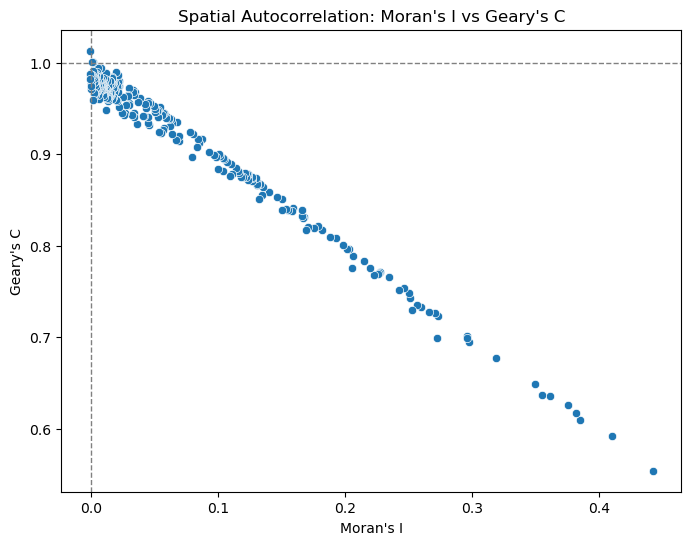

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract results
moran = adata.uns['moranI'].copy()
geary = adata.uns['gearyC'].copy()

# Merge on gene names (index)
df = moran[['I']].rename(columns={'I': 'Moran_I'}).join(geary[['C']].rename(columns={'C': 'Geary_C'}))

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Moran_I', y='Geary_C')
plt.xlabel("Moran's I")
plt.ylabel("Geary's C")
plt.title("Spatial Autocorrelation: Moran's I vs Geary's C")
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.axhline(1, color='gray', linestyle='--', linewidth=1)
plt.show()

Moran’s I typically ranges from -1 (perfect dispersion) to +1 (perfect correlation).

Geary’s C is roughly 0 to 2, where values <1 indicate positive spatial autocorrelation.

The dashed lines at Moran’s I = 0 and Geary’s C = 1 mark "no autocorrelation" baselines.

In [11]:
import anndata as ad

# Load the .h5ad file
adata_h5ad = ad.read_h5ad(os.path.join("..", "datasets", "GSM6592055_M8.h5ad"))

In [12]:
# Optional normalization
sc.pp.normalize_total(adata_h5ad)
sc.pp.log1p(adata_h5ad)

# Compute neighbors graph based on spatial coords
sq.gr.spatial_neighbors(adata_h5ad, coord_type="generic")

# Calculate Moran's I spatial autocorrelation
sq.gr.spatial_autocorr(adata_h5ad, mode="moran")

print(adata_h5ad.uns["moranI"].head())

c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\scanpy\metrics\_common.py:72: UserWarning: 13882 variables were constant, will return nan for these.
  warnings.warn(


                        I  pval_norm  var_norm  pval_norm_fdr_bh
ENSG00000211592  0.339134        0.0  0.000066               NaN
ENSG00000211896  0.318896        0.0  0.000066               NaN
ENSG00000211897  0.312136        0.0  0.000066               NaN
ENSG00000198804  0.263959        0.0  0.000066               NaN
ENSG00000211895  0.246520        0.0  0.000066               NaN


In [13]:
sq.gr.spatial_autocorr(adata_h5ad, mode='geary')

# Results are stored in adata.uns['gearyC']
print(adata_h5ad.uns['gearyC'].head())

c:\Users\rebec\miniforge3\envs\mapra_me\Lib\site-packages\scanpy\metrics\_common.py:72: UserWarning: 13882 variables were constant, will return nan for these.
  warnings.warn(


                        C      pval_norm  var_norm  pval_norm_fdr_bh
ENSG00000211592  0.660499   0.000000e+00  0.000066               NaN
ENSG00000211896  0.682020   0.000000e+00  0.000066               NaN
ENSG00000211897  0.687786   0.000000e+00  0.000066               NaN
ENSG00000237125  0.692032   0.000000e+00  0.000066               NaN
ENSG00000174469  0.723245  3.848527e-254  0.000066               NaN


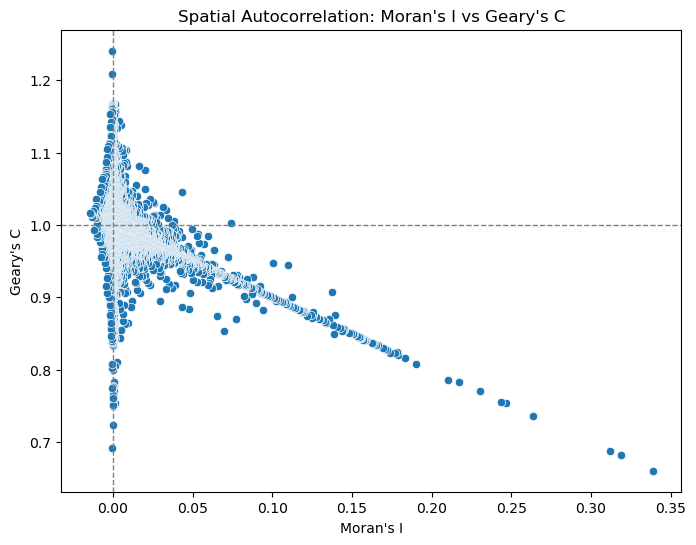

In [14]:
# Extract results
moran_h5ad = adata_h5ad.uns['moranI'].copy()
geary_h5ad = adata_h5ad.uns['gearyC'].copy()

# Merge on gene names (index)
df_h5ad = moran_h5ad[['I']].rename(columns={'I': 'Moran_I'}).join(geary_h5ad[['C']].rename(columns={'C': 'Geary_C'}))

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_h5ad, x='Moran_I', y='Geary_C')
plt.xlabel("Moran's I")
plt.ylabel("Geary's C")
plt.title("Spatial Autocorrelation: Moran's I vs Geary's C")
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.axhline(1, color='gray', linestyle='--', linewidth=1)
plt.show()